<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day3_Exercises_XP_ninja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercises XP ninja


In [1]:
# ============================================================
# ÉTAPE 1 : Chargement et Exploration des données
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, linregress
import urllib.request
import zipfile
import os

# ------------------------------------------------------------
# Téléchargement et extraction du dataset
# ------------------------------------------------------------
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/W4%20Gen%20AI/W4D3/Weight%20vs%20Age%20of%20chicks%20on%20different%20diets.zip"
urllib.request.urlretrieve(url, "chicks.zip")

with zipfile.ZipFile("chicks.zip", "r") as zip_ref:
    zip_ref.extractall("chicks_data")

# Lister les fichiers extraits pour identifier le bon fichier à charger
for root, dirs, files in os.walk("chicks_data"):
    for f in files:
        print(os.path.join(root, f))

chicks_data/ChickWeight.csv


In [2]:
# ------------------------------------------------------------
# Chargement du fichier
# ------------------------------------------------------------
df = pd.read_csv("chicks_data/ChickWeight.csv")

# ------------------------------------------------------------
# Exploration structurelle
# ------------------------------------------------------------
print("=== Aperçu des données ===")
print(df.head())

print("\n=== Dimensions ===")
print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")

print("\n=== Types de données ===")
print(df.dtypes)

print("\n=== Valeurs manquantes ===")
print(df.isnull().sum())

print("\n=== Statistiques descriptives ===")
print(df.describe())

print("\n=== Colonnes disponibles ===")
print(df.columns.tolist())

=== Aperçu des données ===
   Unnamed: 0  weight  Time  Chick  Diet
0           1      42     0      1     1
1           2      51     2      1     1
2           3      59     4      1     1
3           4      64     6      1     1
4           5      76     8      1     1

=== Dimensions ===
578 lignes, 5 colonnes

=== Types de données ===
Unnamed: 0    int64
weight        int64
Time          int64
Chick         int64
Diet          int64
dtype: object

=== Valeurs manquantes ===
Unnamed: 0    0
weight        0
Time          0
Chick         0
Diet          0
dtype: int64

=== Statistiques descriptives ===
       Unnamed: 0      weight        Time       Chick        Diet
count  578.000000  578.000000  578.000000  578.000000  578.000000
mean   289.500000  121.818339   10.717993   25.750865    2.235294
std    166.998503   71.071960    6.758400   14.568795    1.162678
min      1.000000   35.000000    0.000000    1.000000    1.000000
25%    145.250000   63.000000    4.000000   13.000000    1

In [3]:
# ------------------------------------------------------------
# Nettoyage des données
# ------------------------------------------------------------

# Suppression de la colonne d'index résiduelle (inutile pour l'analyse)
df = df.drop(columns=['Unnamed: 0'])

# Conversion de 'Diet' en catégorie : ce n'est pas une variable numérique continue,
# mais une étiquette de groupe (1, 2, 3, 4 = 4 régimes différents)
df['Diet'] = df['Diet'].astype('category')

print("=== Vérification après nettoyage ===")
print(df.dtypes)
print(f"\nNombre de poussins uniques : {df['Chick'].nunique()}")
print(f"Âges mesurés (Time, en jours) : {sorted(df['Time'].unique())}")
print(f"\nRépartition des poussins par régime :")
print(df.groupby('Diet')['Chick'].nunique())

=== Vérification après nettoyage ===
weight       int64
Time         int64
Chick        int64
Diet      category
dtype: object

Nombre de poussins uniques : 50
Âges mesurés (Time, en jours) : [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18), np.int64(20), np.int64(21)]

Répartition des poussins par régime :
Diet
1    20
2    10
3    10
4    10
Name: Chick, dtype: int64


/tmp/ipykernel_713/125337551.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Diet')['Chick'].nunique())


/tmp/ipykernel_713/3150598055.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


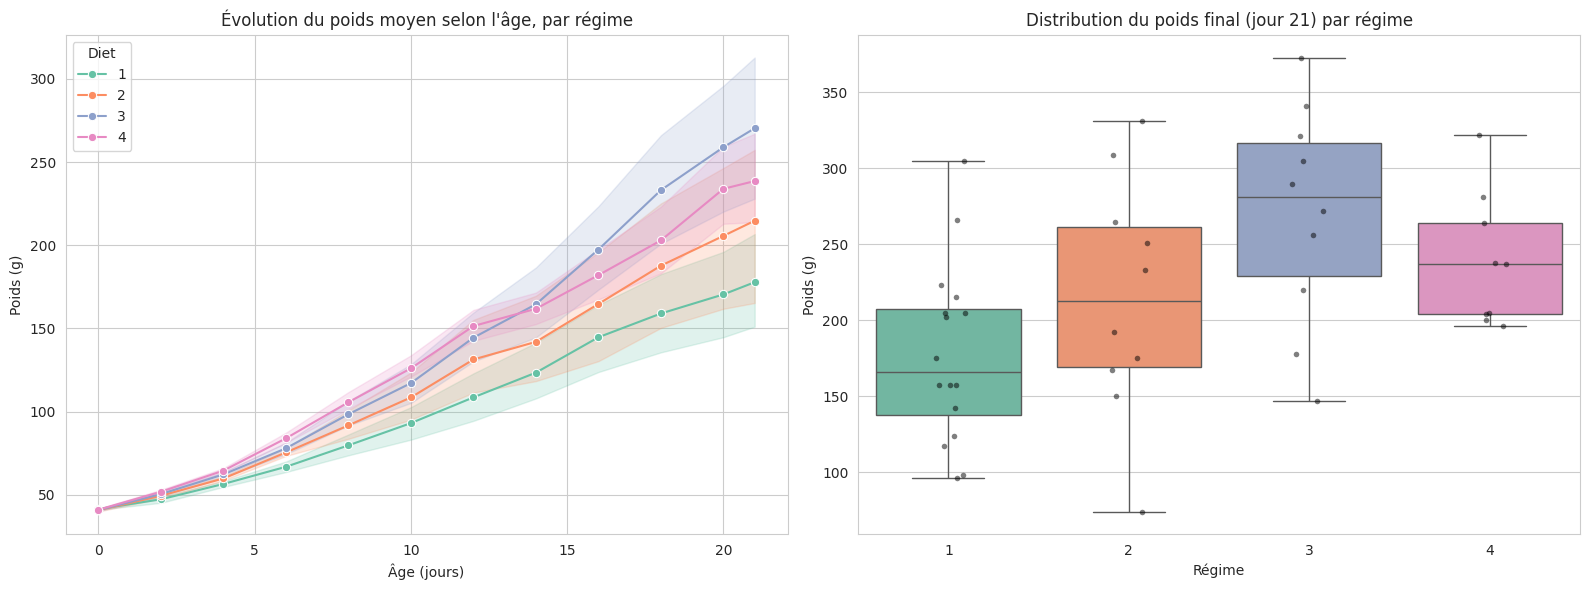

=== Statistiques du poids au jour 21, par régime ===
      count        mean        std    min    25%    50%    75%    max
Diet                                                                 
1      16.0  177.750000  58.702073   96.0  137.5  166.0  207.5  305.0
2      10.0  214.700000  78.138126   74.0  169.0  212.5  261.5  331.0
3      10.0  270.300000  71.622545  147.0  229.0  281.0  317.0  373.0
4       9.0  238.555556  43.347754  196.0  204.0  237.0  264.0  322.0


In [6]:
# ============================================================
# ÉTAPE 2 : Visualisation - Poids vs Âge par Régime
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------
# Graphique 1 : Évolution du poids moyen avec l'âge, par régime
# ------------------------------------------------------------
# seaborn calcule automatiquement la moyenne + intervalle de confiance (zone ombrée)
# à chaque point de temps, pour chaque régime
sns.lineplot(
    data=df, x='Time', y='weight', hue='Diet',
    marker='o', ax=axes[0], palette='Set2'
)
axes[0].set_title("Évolution du poids moyen selon l'âge, par régime")
axes[0].set_xlabel("Âge (jours)")
axes[0].set_ylabel("Poids (g)")

# ------------------------------------------------------------
# Graphique 2 : Distribution du poids final (jour 21) par régime
# ------------------------------------------------------------
# On isole uniquement la dernière mesure (jour 21) pour comparer
# le résultat final de chaque régime, sans l'effet "trajectoire"
final_weights = df[df['Time'] == 21]

sns.boxplot(
    data=final_weights, x='Diet', y='weight', ax=axes[1], palette='Set2'
)
sns.stripplot(
    data=final_weights, x='Diet', y='weight', ax=axes[1],
    color='black', alpha=0.5, size=4
)
axes[1].set_title("Distribution du poids final (jour 21) par régime")
axes[1].set_xlabel("Régime")
axes[1].set_ylabel("Poids (g)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Statistiques descriptives du poids final par régime
# ------------------------------------------------------------
print("=== Statistiques du poids au jour 21, par régime ===")
print(final_weights.groupby('Diet', observed=True)['weight'].describe())

In [7]:
# ============================================================
# ÉTAPE 3 : Test ANOVA sur le poids au jour 21
# ============================================================

from scipy.stats import f_oneway

# On reprend le sous-ensemble du jour 21 défini à l'étape précédente
final_weights = df[df['Time'] == 21]

# Séparation des poids par régime (nécessaire car f_oneway attend des échantillons séparés)
groups = [
    final_weights[final_weights['Diet'] == diet]['weight']
    for diet in final_weights['Diet'].cat.categories
]

f_stat, p_value = f_oneway(*groups)

print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < alpha ({alpha}) -> on REJETTE H0")
    print("Conclusion : le régime alimentaire a un effet statistiquement significatif sur le poids au jour 21.")
else:
    print(f"\np-value ({p_value:.4f}) >= alpha ({alpha}) -> on NE rejette PAS H0")
    print("Conclusion : pas de preuve statistique suffisante d'un effet du régime sur le poids final.")

F-statistic : 4.6547
p-value     : 0.0069

p-value (0.0069) < alpha (0.05) -> on REJETTE H0
Conclusion : le régime alimentaire a un effet statistiquement significatif sur le poids au jour 21.


In [8]:
# ============================================================
# ÉTAPE 3 (suite) : Vérification des hypothèses + Test Post-Hoc
# ============================================================

from scipy.stats import levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ------------------------------------------------------------
# 1) TEST DE LEVENE : homogénéité des variances
# ------------------------------------------------------------
# H0 : les variances sont égales entre les groupes
# H1 : au moins une variance diffère
levene_stat, levene_p = levene(*groups)

print("=== Test de Levene (homogénéité des variances) ===")
print(f"Statistic : {levene_stat:.4f}")
print(f"p-value   : {levene_p:.4f}")

if levene_p < 0.05:
    print("-> Les variances sont significativement différentes entre groupes.")
    print("   L'hypothèse d'homoscédasticité de l'ANOVA classique est violée.")
    print("   Il serait plus prudent d'utiliser le test de Welch (ANOVA robuste).")
else:
    print("-> Pas de différence significative de variance entre groupes.")
    print("   L'ANOVA classique reste valide sur ce point.")

# ------------------------------------------------------------
# 2) TEST POST-HOC DE TUKEY : quelles paires de régimes diffèrent ?
# ------------------------------------------------------------
tukey_result = pairwise_tukeyhsd(
    endog=final_weights['weight'],      # variable mesurée
    groups=final_weights['Diet'],        # groupes à comparer
    alpha=0.05
)

print("\n=== Test post-hoc de Tukey HSD ===")
print(tukey_result)

=== Test de Levene (homogénéité des variances) ===
Statistic : 1.1597
p-value   : 0.3367
-> Pas de différence significative de variance entre groupes.
   L'ANOVA classique reste valide sur ce point.

=== Test post-hoc de Tukey HSD ===
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2    36.95 0.4868  -32.1106 106.0106  False
     1      3    92.55 0.0047   23.4894 161.6106   True
     1      4  60.8056 0.1193  -10.5771 132.1882  False
     2      3     55.6 0.2264  -21.0159 132.2159  False
     2      4  23.8556 0.8487  -54.8598 102.5709  False
     3      4 -31.7444 0.7036 -110.4598  46.9709  False
-------------------------------------------------------


=== Aperçu des taux de croissance individuels ===
   Chick Diet  growth_rate  r_squared
0      1    1     7.987899   0.958798
1      2    1     8.719861   0.980997
2      3    1     8.487370   0.978738
3      4    1     6.088640   0.974457
4      5    1    10.055362   0.966927

=== Taux de croissance moyen par régime (g/jour) ===
      count       mean       std       min       25%        50%        75%  \
Diet                                                                         
1      19.0   6.260875  3.404184  1.053571  3.899410   6.088640   8.463999   
2      10.0   8.609136  4.047365  1.207533  6.095258   8.541522  11.005861   
3      10.0  11.422871  3.534349  5.855241  9.999395  11.398805  13.376948   
4      10.0   9.523550  2.219170  6.354545  8.199629   9.046438  10.934314   

            max  
Diet             
1     13.205264  
2     15.475117  
3     17.258811  
4     13.714718  


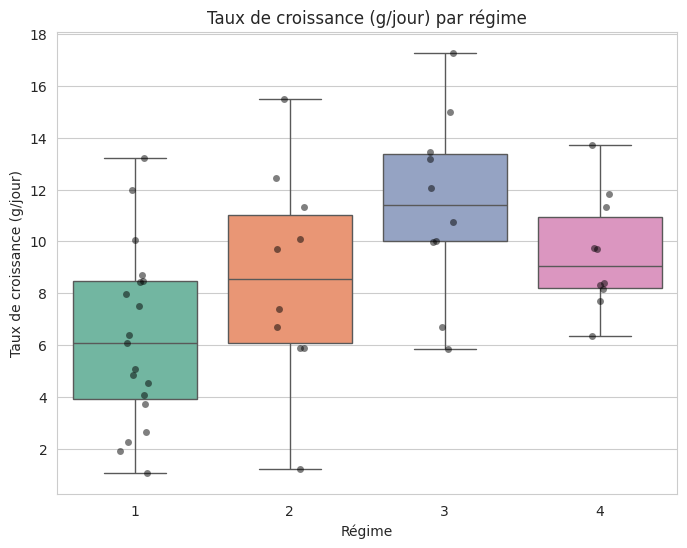


=== ANOVA sur le taux de croissance ===
F-statistic : 5.5933
p-value     : 0.0024
-> Le régime a un effet statistiquement significatif sur la VITESSE de croissance.

=== Test post-hoc de Tukey HSD (taux de croissance) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   2.3483 0.2959 -1.1699 5.8664  False
     1      3    5.162 0.0017  1.6438 8.6801   True
     1      4   3.2627 0.0779 -0.2555 6.7808  False
     2      3   2.8137  0.258 -1.2135  6.841  False
     2      4   0.9144 0.9297 -3.1128 4.9416  False
     3      4  -1.8993 0.5938 -5.9266 2.1279  False
---------------------------------------------------


In [12]:
# ================================================================
# ÉTAPE 4 : Analyse du taux de croissance par régime
# ================================================================

from scipy.stats import linregress, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------
# Calcul du taux de croissance (pente) pour chaque poussin individuellement
# ----------------------------------------------------------------
growth_rates = []

for chick_id, chick_data in df.groupby('Chick', observed=True):
    # On ne garde que les poussins avec au moins 3 mesures dans le temps
    if len(chick_data) >= 3:
        slope, intercept, r_value, p_val, std_err = linregress(
            chick_data['Time'], chick_data['weight']
        )
        growth_rates.append({
            'Chick': chick_id,
            'Diet': chick_data['Diet'].iloc[0],
            'growth_rate': slope,
            'r_squared': r_value ** 2
        })

growth_df = pd.DataFrame(growth_rates)

# Re-typage explicite : nécessaire car construire un DataFrame depuis une liste
# de dicts ne préserve PAS automatiquement le dtype 'category' d'origine
growth_df['Diet'] = growth_df['Diet'].astype('category')

print("=== Aperçu des taux de croissance individuels ===")
print(growth_df.head())

print("\n=== Taux de croissance moyen par régime (g/jour) ===")
print(growth_df.groupby('Diet', observed=True)['growth_rate'].describe())

# ----------------------------------------------------------------
# Visualisation : distribution des taux de croissance par régime
# ----------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(data=growth_df, x='Diet', y='growth_rate', hue='Diet', palette='Set2', legend=False)
sns.stripplot(data=growth_df, x='Diet', y='growth_rate', color='black', alpha=0.5, size=5)
plt.title("Taux de croissance (g/jour) par régime")
plt.xlabel("Régime")
plt.ylabel("Taux de croissance (g/jour)")
plt.show()

# ----------------------------------------------------------------
# ANOVA sur les taux de croissance
# ----------------------------------------------------------------
growth_groups = [
    growth_df[growth_df['Diet'] == diet]['growth_rate']
    for diet in growth_df['Diet'].cat.categories
]

f_stat_growth, p_value_growth = f_oneway(*growth_groups)

print(f"\n=== ANOVA sur le taux de croissance ===")
print(f"F-statistic : {f_stat_growth:.4f}")
print(f"p-value     : {p_value_growth:.4f}")

if p_value_growth < 0.05:
    print("-> Le régime a un effet statistiquement significatif sur la VITESSE de croissance.")
else:
    print("-> Pas de preuve statistique suffisante d'un effet du régime sur la vitesse de croissance.")

# ----------------------------------------------------------------
# Test post-hoc de Tukey sur le taux de croissance
# ----------------------------------------------------------------
tukey_growth = pairwise_tukeyhsd(
    endog=growth_df['growth_rate'],
    groups=growth_df['Diet'],
    alpha=0.05
)

print("\n=== Test post-hoc de Tukey HSD (taux de croissance) ===")
print(tukey_growth)

# Analysis of Diet Effects on Chick Growth

## 1. Introduction

This report investigates whether different diets have a statistically
significant effect on the growth of chicks, using the classic **ChickWeight**
dataset. The dataset contains 578 weight measurements taken from 50 chicks,
recorded at 12 time points between day 0 and day 21, across 4 different diets.

## 2. Data Exploration

| Diet | Number of chicks (initial) |
|------|------------------------------|
| 1    | 20                            |
| 2    | 10                            |
| 3    | 10                            |
| 4    | 10                            |

No missing values were found in the dataset. However, by day 21, only
16 chicks remained on Diet 1 and 9 on Diet 4 — indicating that some chicks
did not survive or were removed from the study before its end. This is a
known limitation of the dataset and is discussed further in Section 6.

## 3. Visualization

Two visualizations were used:
- A **line plot** of mean weight over time, by diet, showing the overall
  growth trajectory of each group.
- A **boxplot** of final weight (day 21) by diet, to compare endpoint outcomes
  independently of growth trajectory.

Both visualizations suggested that **Diet 3** produced the highest average
final weight and the steepest growth curve, while **Diet 1** showed the
lowest average final weight and the most variability.

## 4. Statistical Testing — Final Weight (Day 21)

A one-way ANOVA was performed to test whether mean final weight differs
significantly across diets.

| Metric | Value |
|---|---|
| F-statistic | 4.65 |
| p-value | 0.0069 |

Since p < 0.05, we **reject the null hypothesis**: diet has a statistically
significant effect on final chick weight.

**Assumption check (Levene's test):** p = 0.337 (≥ 0.05) → variances are
homogeneous across groups, confirming that the standard ANOVA was appropriate
to use here.

**Post-hoc analysis (Tukey HSD):** Only one pairwise comparison was
statistically significant:

| Comparison | Mean difference (g) | p-adj | Significant? |
|---|---|---|---|
| Diet 1 vs Diet 3 | +92.55 | 0.0047 | **Yes** |
| Diet 1 vs Diet 2 | +36.95 | 0.487 | No |
| Diet 1 vs Diet 4 | +60.81 | 0.119 | No |
| Diet 2 vs Diet 3 | +55.60 | 0.226 | No |
| Diet 2 vs Diet 4 | +23.86 | 0.849 | No |
| Diet 3 vs Diet 4 | -31.74 | 0.704 | No |

This shows that the overall significant ANOVA result is driven almost
entirely by the difference between **Diet 1 and Diet 3**. Other visually
apparent gaps (e.g., Diet 1 vs Diet 4) are not statistically reliable given
the small sample sizes.

## 5. Growth Rate Analysis

To complement the endpoint analysis, an individual growth rate (grams/day)
was estimated for each chick via simple linear regression of weight on time,
then compared across diets.

| Diet | Mean growth rate (g/day) | Std dev |
|---|---|---|
| 1 | 6.26 | 3.40 |
| 2 | 8.61 | 4.05 |
| **3** | **11.42** | 3.53 |
| 4 | 9.52 | 2.22 |

A one-way ANOVA confirmed a statistically significant effect of diet on
growth rate:

| Metric | Value |
|---|---|
| F-statistic | 5.59 |
| p-value | 0.0024 |

**Post-hoc analysis (Tukey HSD)** again identified **Diet 1 vs Diet 3** as
the only statistically significant pairwise difference (mean difference =
5.16 g/day, p-adj = 0.0017).

## 6. Discussion and Limitations

- **Convergent evidence**: Both final weight and growth rate analyses point
  to the same conclusion — Diet 3 produces significantly faster and greater
  growth than Diet 1, while differences among Diets 2, 3, and 4 are not
  statistically distinguishable from each other.
- **Unequal group sizes**: Diet 1 had twice as many chicks as the other
  groups, and attrition by day 21 further unbalanced the sample sizes (16
  vs 9-10). This reduces statistical power for some comparisons and should
  be considered when interpreting non-significant results (absence of proof
  is not proof of absence).
- **Survivorship bias**: chicks that did not survive to day 21 were excluded
  from the final-weight analysis, which could slightly bias results toward
  diets associated with healthier or faster-developing chicks.
- **Correlation vs causation**: although this is an experimental setup
  (diets were presumably assigned, not self-selected), unmeasured factors
  (e.g., individual chick health at baseline) could still influence results.

## 7. Conclusion

Diet has a statistically significant effect on both the final weight and the
growth rate of chicks. Specifically, **Diet 3 leads to significantly faster
and greater growth compared to Diet 1**. Differences between the remaining
diet pairs were not statistically significant, suggesting that, with the
current sample size, only the most extreme difference (Diet 1 vs Diet 3) can
be detected with confidence. A larger, balanced sample would be needed to
draw firmer conclusions about the relative effectiveness of Diets 2 and 4.